In [1]:
## load all libraries

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_percentage_error,mean_absolute_percentage_error
from statsmodels.tsa.seasonal import STL
import numpy as np
from pandas import Series, DataFrame
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import register_matplotlib_converters
import pmdarima as pm
register_matplotlib_converters()
import warnings
import time
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from numpy import array
import keras_tuner as kt
import tensorflow as tf
print(tf.__version__)
from tensorflow import keras
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Bidirectional
from keras.models import Sequential
from keras.preprocessing.sequence import TimeseriesGenerator
from keras.layers import Bidirectional
from tensorflow.keras import initializers
import random as rn
np.random.seed(123)
rn.seed(123)
tf.random.set_seed(123)
tf.keras.utils.set_random_seed(123)
keras.utils.set_random_seed(123)
warnings.filterwarnings('ignore')

## Load the dataset
df = pd.read_csv('favorita_train.csv')


2.10.0


0.10946265252903833
1.0055096418732783
0.6165026876327258
0.2404435317937204
1.0055096418732783
0.714541134552447
0.22306023178865916
1.0101476014760147
0.6408304245518702
0.21960228145832672
1.0055096418732783
0.8160741914397722
0.09727172824857505
1.0055096418732783
0.655950043067225
0.1654652327982432
1.012014787430684
0.6475051601430974
0.2753500968931705
1.0055096418732783
0.657892913495739
0.09484575156261651
1.0055096418732783
0.6318492907723161
0.32529193576786936
1.0176579925650557
0.6304301056805814
0.23732686760626737
1.0092165898617511
0.6099422041497384
0.13837671519852804
1.0055096418732783
0.7841411923969581
0.23646750580678622
1.0055096418732783
0.6292191262547145
0.22086735045980432
1.0055096418732783
0.8232090426912196
0.14728784560424085
1.0055096418732783
0.6767679602537344
0.2589542905764977
1.0055096418732783
0.613285511749819
0.1487387452456994
1.0055096418732783
0.6375103900248024
0.46920505395630635
1.0252808988764044
0.6078303443414929
0.3467395472260437
1.006

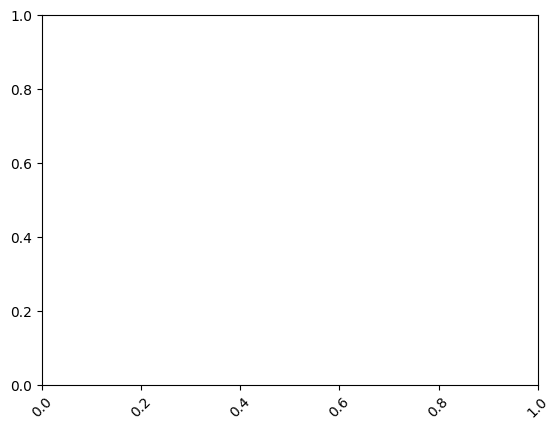

In [4]:
# iterate all items from all stores
import os 
category ='smoothy_sf_65'
os.mkdir(category)
stats = pd.DataFrame(columns=['store_nbr','item_nbr','adfPValue', 'adi', 'sd', 'mean', 'cv2', 'arima_r2','arima_mse','arima_rmse','arima_mape','lr','units','layers','best_epoch','lstm_r2','lstm_mse','lstm_rmse','lstm_mape'])
sf_list = []
scaler = MinMaxScaler()
nbr_of_ts=100 # number of time series to take 
counter = 1
ts_number = 100
accepted_series_length= 1095 # time series length to take (start from jan 2013) 3years == 1095
for store_nbr in df['store_nbr'].unique():
    if counter > nbr_of_ts :
        break
        
    df1=0
    df1 = df[df['store_nbr']==store_nbr]
    for item_nbr in df1['item_nbr'].unique():
        if counter > nbr_of_ts :
            break
        
        t = time.time()

        df2=0
        df3=0
        df2 = df1[df1['item_nbr']==item_nbr]
        if len(df2)>10 : #a TS should at least have some points 
        
            df2['date']=pd.to_datetime(df2['date'])
            df2['Week'] = df2['date'].dt.week
            df2['Month'] = df2['date'].dt.month
            df2['Year'] = df2['date'].dt.year
            month=df2["Month"].values[1]
            year=df2["Year"].values[1]
            df3 = df2.groupby(['date']).agg({'date':'max' ,'unit_sales':'mean'})
            df3.set_index('date',inplace=True)
            df3.sort_index(inplace=True)

            if len(df3)>accepted_series_length : 
                
                if  year==2013 and month==1 :
                    new_date_range = pd.date_range(start="2013-01-01", end="2017-08-15", freq="D") # replace non existe=ing values with zeros
                    df3=df3.reindex(new_date_range, fill_value=0)
                    tempo=0;
                    df3['idx'] = range(0, len(df3))
                    mean=df3['unit_sales'].mean()
                    # clip negative values to zero
                    for index, row in df3.iterrows():
                        if row['unit_sales']<0:
                            idx=row['idx']
                            df3.iat[int(idx), df3.columns.get_loc('unit_sales')] = 0
                        if row['unit_sales']==0.0:
                            #df.at[df3['idx'],'idx']=tempo;
                            idx=row['idx']
                            df3.iat[int(idx), df3.columns.get_loc('unit_sales')] = 0
                        #else:    
                    df3=df3.drop(columns=['idx'])
                    df3=df3[:accepted_series_length] #3years
                    # get data characteristics
                    train_all = df3.iloc[:accepted_series_length]
                    scaler.fit(train_all)
                    scaled_all = scaler.transform(df3)
                    adi = len(scaled_all)/((scaled_all != 0).sum())
                    sd=scaled_all.std()
                    mean=scaled_all.mean()
                    cv2 = np.square(sd/mean)

                    ts_number=ts_number+1

                    results = seasonal_decompose(df3['unit_sales'])
                    SF=np.maximum(0,1-np.var(results.resid)/np.var(results.seasonal+results.resid))
                    
                    # work only on data in the following range
                    if SF < 0.6 or cv2 > 0.48 or  adi>1.1 : #smooth  
                    #if SF > 0.9 or SF < 0.7 or cv2 < 0.49 or cv2 > 1.3 or adi>1.2 : #'''erratic'''
                    #if SF > 0.57 or SF < 0.53 or cv2 > 0.5 or  adi<1.25 : #  intermittent
                    #if SF > 0.9 or SF < 0.6 or cv2 < 0.49 or  adi<1.32 : # lumpy
                    #if cv2 > 0.55 or  adi<1.22 : #  intermittent
                        continue;
                    sf_list.append(SF)
                    
                    df3.to_csv(category+'/'+str(store_nbr)+'_'+str(item_nbr)+'.csv')  
                    
                    results = seasonal_decompose(df3['unit_sales'])
                    plt.xticks(rotation=45)
                    results.plot();
                    plt.savefig(category+'/'+str(store_nbr)+'_'+str(item_nbr)+'.png')  
                    plt.close()
                    
                    print(cv2)
                    print(adi)
                    print(SF)
                    
                    counter = counter +1
                    #do this only on a limited nbr of TS
                    
                    #### code to work on each TS 
                    
                    '''
                    # stl decomposition 
                    stl_analysis(df3['unit_sales'],store_nbr, item_nbr,category) 
                    
                    # save cv2, adi, sd, mean, stationarity and get scaled data
                    adfPValue,adi,sd,mean,cv2,scaled_train_all,scaled_train,scaled_val,scaled_val,scaled_test = data_scaling_and_getting_characteristics(df3)

                    
                    # perform arima forecasting 
                    arima_prediction, arima_fitted,arima_r2,arima_mse,arima_rmse,arima_mape = arima_forecasting(scaled_train_all,scaled_val,scaled_test)
                    
                    # perform LSTM forecasting 
                    lr,units,layers,best_epoch,lr,lstm_predictions,lstm_fit,lstm_r2,lstm_mse,lstm_rmse,lstm_mape=lstm_forecasting(scaled_train_all,scaled_train,scaled_val,scaled_test,category, store_nbr, item_nbr)
                        
                    # Save results to a table
                    values_to_add = {'store_nbr':str(store_nbr),'item_nbr':str(item_nbr),'adfPValue': adfPValue, 'adi': adi,'sd': sd,'mean': mean,'cv2': cv2,'arima_r2': arima_r2,'arima_mse': arima_mse,'arima_rmse': arima_rmse,'arima_mape': arima_mape, 'lr':lr,'units':units,'layers':layers,'best_epoch':best_epoch,'lstm_r2': lstm_r2,'lstm_mse': lstm_mse,'lstm_rmse': lstm_rmse,'lstm_mape': lstm_mape }
                    row_to_add = pd.Series(values_to_add, name='x')
                    stats = stats.append(row_to_add)
                    
                    # save graphs to an image
                    save_forecast_image(scaled_train_all,arima_fitted,arima_prediction,lstm_fit,lstm_predictions,category, store_nbr, item_nbr)
                    
                    
                    #### end of code of each timeseries
                    '''

In [16]:
df = pd.read_csv('smooth_45/1_1004551.csv')
df.columns = ['date', 'unit_sales']
df.set_index('date',inplace=True)

In [11]:
# iterate all items from all stores
import os 
counter = 1
for store_nbr in df['store_nbr'].unique():
    if counter > nbr_of_ts :
        break
        
    df1=0
    df1 = df[df['store_nbr']==store_nbr]
    for item_nbr in df1['item_nbr'].unique():
        df2 = df1[df1['item_nbr']==item_nbr]
        if len(df2)>50 : #a TS should at least have some points 
            counter = counter+1
        


In [12]:
counter

3220